In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow import keras

I0000 00:00:1776636730.914276   32840 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776636730.914642   32840 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776636730.956329   32840 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776636732.119417   32840 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

E0000 00:00:1776636733.005179   32840 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776636733.005498   32892 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776636733.023531   32840 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,074 (15.91 KB)

 Trainable params: 4,074 (15.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 8s 963us/step - accuracy: 0.4708 - loss: 1.0325 - val_accuracy: 0.0000e+00 - val_loss: 9.2313
Epoch 2/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 7s 932us/step - accuracy: 0.4951 - loss: 1.0068 - val_accuracy: 0.0000e+00 - val_loss: 10.8849
Epoch 3/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 7s 925us/step - accuracy: 0.5006 - loss: 1.0017 - val_accuracy: 0.0000e+00 - val_loss: 13.0049
Epoch 4/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 7s 955us/step - accuracy: 0.5065 - loss: 0.9951 - val_accuracy: 0.0000e+00 - val_loss: 16.5672
Epoch 5/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 7s 965us/step - accuracy: 0.5178 - loss: 0.9812 - val_accuracy: 0.0000e+00 - val_loss: 16.5430
Epoch 6/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 7s 984us/step - accuracy: 0.5265 - loss: 0.9669 - val_accuracy: 0.0000e+00 - val_loss: 16.8607
Epoch 7/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 7s 997us/step - accuracy: 0.5350 - loss: 0.9536 - val_accuracy: 0.0000e+00 - val_loss: 17.7762
Epoch 8/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 

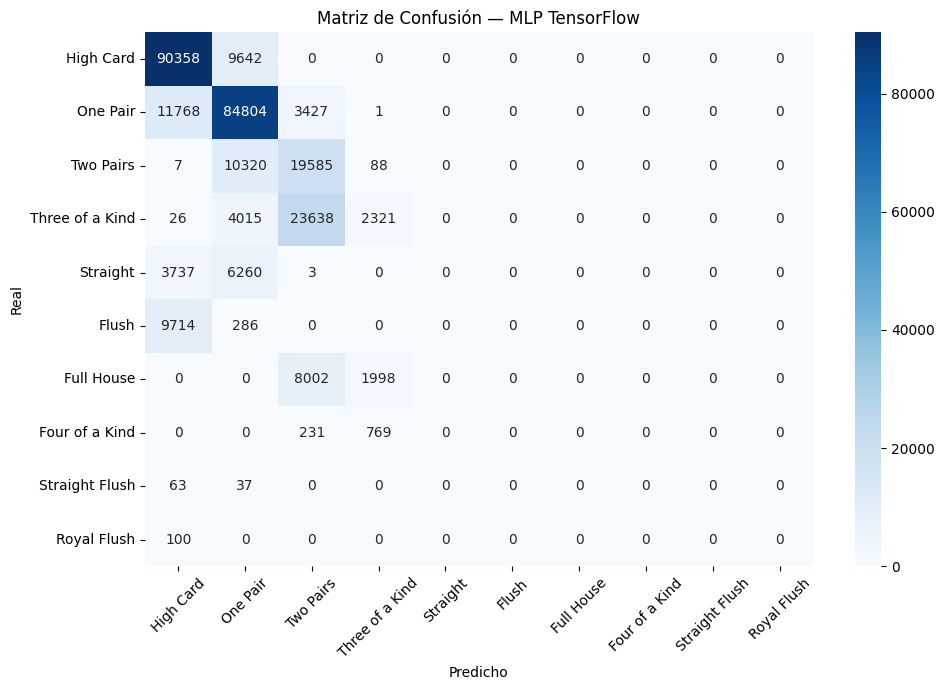

In [ ]:
# Se lee el dataset preprocesado
df = pd.read_csv('../preprocesamiento/preprocesamiento_trainning.data', header=None)
x = df.iloc[:, :-1]
y = df.iloc[:, -1]
clases = sorted(y.unique().astype(int).tolist())
clase_nombres = {
    0: "High Card", 1: "One Pair", 2: "Two Pairs", 3: "Three of a Kind",
    4: "Straight",  5: "Flush",   6: "Full House", 7: "Four of a Kind",
    8: "Straight Flush", 9: "Royal Flush"
}
nombres_ordenados = [clase_nombres[c] for c in clases]


# Todas las columnas excepto la última
# Última columna
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Número de clases distintas
# Número de características (features) por muestra
n_clases = len(np.unique(y))
n_features = x.shape[1]


modelo_tf = keras.Sequential([    
    # Capa de entrada: recibe vectores de tamaño n_features
    keras.layers.Input(shape=(n_features,)),
    # Primera capa oculta con 64 neuronas y activación ReLU
    keras.layers.Dense(64, activation='relu'),
    # Segunda capa oculta con 32 neuronas y activación ReLU
    keras.layers.Dense(32, activation='relu'),
    # Capa de salida:
    # n_clases neuronas (una por clase)
    # softmax convierte las salidas en probabilidades
    keras.layers.Dense(n_clases, activation='softmax')
])

# Compilación del modelo:
modelo_tf.compile(
    optimizer='adam',  # algoritmo de optimización
    loss='sparse_categorical_crossentropy',  
    # Se usa porque y NO está en one-hot, sino como etiquetas enteras
    metrics=['accuracy']  # métrica de evaluación
)

# Muestra un resumen del modelo (capas, parámetros, etc.)
modelo_tf.summary()


history = modelo_tf.fit(
    x, y,
    epochs=10,          # número de iteraciones completas sobre el dataset
    batch_size=32,      # tamaño de lote
    validation_split=0.2,  # 20% de los datos se usan para validación
    verbose=1           # muestra progreso en consola
)

# Predicciones del modelo (probabilidades por clase)
y_pred_tf = np.argmax(modelo_tf.predict(x), axis=1)

# Se usa argmax para convertir probabilidades en la clase con mayor valor


# Accuracy: proporción de aciertos
print(f"Accuracy : {accuracy_score(y, y_pred_tf):.4f}")
# Recall macro: promedio del recall por clase (útil en datasets desbalanceados)
print(f"Recall   : {recall_score(y, y_pred_tf, average='macro', zero_division=0):.4f}")
# F1-score macro: balance entre precisión y recall por clase
print(f"F1       : {f1_score(y, y_pred_tf, average='macro', zero_division=0):.4f}")


# Calcula la matriz de confusión
cm_tf = confusion_matrix(y, y_pred_tf)

# Se grafica con seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_tf, 
    annot=True,        # muestra números dentro de cada celda
    fmt='d',           # formato entero
    cmap='Blues',      # esquema de colores
    xticklabels=nombres_ordenados,
    yticklabels=nombres_ordenados,
)

# Etiquetas del gráfico
plt.title("Matriz de Confusión — MLP TensorFlow")
plt.xlabel("Predicho")
plt.ylabel("Real")

# Ajustes visuales
plt.tick_params(axis='x', rotation=45)
plt.tick_params(axis='y', rotation=0)
plt.tight_layout()

# Mostrar gráfico
plt.show()